In [1]:
import json
# import plotly.express as px
import pandas as pd
# import openpyxl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Tender schedule with starting point

In [2]:
with open('MMR_Penta_S2_D2_overlap_cap.json') as json_file:
    F_results = json.load(json_file)


In [5]:
# Search results by keyword for F (tender schedules)
# List of keywords to search for
keywords_to_search = ["X"]

# Initialize a dictionary to store grouped results
grouped_results = {keyword: [] for keyword in keywords_to_search}

# Search for keywords in the JSON keys and group the results
for key, value in F_results.items():
    for keyword in keywords_to_search:
        if keyword in key:
            grouped_results[keyword].append({key: value})


In [7]:
#filter for F and X, to show vaccines allocated per tender

# Extract the 'M' group
m_group = grouped_results.get('X', [])

# Filter dictionaries starting with 'X' or 'F' and exclude those with 'X_tilde'
filtered_dicts = [
    entry for entry in m_group
    if any((key.startswith(('X[', 'F')) and 'X_tilde' not in key) for key in entry)
       and not all(value == 0 for key, value in entry.items())
       and all('HPV' not in key for key in entry)
]

In [9]:
#group the data into X and F

# Function to group items by key start value
def group_by_start_value(items):
    grouped_data = {}

    for item in items:
        key = list(item.keys())[0]  # Extract the key from the dictionary
        start_value = key[0]  # Get the first character of the key
        if start_value not in grouped_data:
            grouped_data[start_value] = []
        grouped_data[start_value].append(item)

    return grouped_data

# Group the data
result = group_by_start_value(filtered_dicts)

result


{'X': [{'X[OPV,Panacea_Biotec,18]': 2050000.0},
  {'X[OPV,Beijing_Institute,26]': 8200000.0},
  {'X[OPV,Beijing_Institute,31]': 8200000.0},
  {'X[Rotavirus,Bharat_Biotech,26]': 41266667.17529297},
  {'X[OPV,Panacea_Biotec,25]': 2050000.0},
  {'X[Penta,LG_Chem,23]': 81933288.57421875},
  {'X[PCV,Serum_Institute,6]': 219100000.0},
  {'X[Penta,LG_Chem,2]': 74600000.0},
  {'X[MMR,Serum_Institute,31]': 558506141.8356833},
  {'X[Rotavirus,Serum_Institute,24]': 196490345.3977526},
  {'X[Penta,Biological_E,3]': 154800000.0},
  {'X[Penta,PT_Bio,32]': 123000000.07152557},
  {'X[OPV,Panacea_Biotec,32]': 2050000.0},
  {'X[PCV,Serum_Institute,1]': 118826666.4},
  {'X[OPV,PT_Bio,33]': 11660000.0},
  {'X[Penta,Panacea_Biotec,5]': 21700000.0},
  {'X[OPV,Panacea_Biotec,5]': 2050000.0},
  {'X[Td,Serum_Institute,1]': 144141644.8},
  {'X[OPV,Haffkine_Bio,32]': 8200000.0},
  {'X[Penta,Serum_Institute,26]': 200440099.8220861},
  {'X[OPV,Beijing_Institute,15]': 8200000.0},
  {'X[Penta,LG_Chem,6]': 79800000.0

In [11]:

# Extracting data for the DataFrame
df_data = []
for entry in result['X']:
    key, value = entry.popitem()
    vaccine = key.split(',')[0][2:]
    producer = key.split(',')[1].strip()
    start = int(key.split(',')[2].split(']')[0])
    end = int(start)
    df_data.append({'Vaccine': vaccine, 'Producer': producer, 'Start': start, 'End': end, 'Value': value})

# Creating DataFrame
X_data = pd.DataFrame(df_data)

# Print the DataFrame
X_data


,Vaccine,Producer,Start,End,Value
0,OPV,Panacea_Biotec,18,18,2.050000e+06
1,OPV,Beijing_Institute,26,26,8.200000e+06
2,OPV,Beijing_Institute,31,31,8.200000e+06
3,Rotavirus,Bharat_Biotech,26,26,4.126667e+07
4,OPV,Panacea_Biotec,25,25,2.050000e+06
...,...,...,...,...,...
518,Penta,Serum_Institute,16,16,1.983108e+08
519,OPV,PT_Bio,20,20,1.166000e+07
520,Rotavirus,Bharat_Biotech,27,27,4.126667e+07
521,OPV,Bharat_Biotech,3,3,3.795607e+07


In [12]:
values = X_data.groupby('Producer).agg({'Value':'sum'})

In [23]:
X_data.groupby(['Producer','Vaccine']).agg({'Value':'sum'})

Value
Producer          Vaccine                
AJ_Vaccines       IPV        1.260000e+07
BB_NCIPD          DT         1.608564e+07
                  TT         3.632301e+07
                  Td         5.302047e+07
Beijing_Institute OPV        2.881000e+08
Bharat_Biotech    OPV        1.343876e+08
                  Rotavirus  1.332168e+09
Bilthoven         IPV        8.400000e+06
Biological_E      DTwP       6.093611e+07
                  MR         7.222332e+07
                  Penta      5.304506e+09
GSK               MMR        9.721623e+08
                  OPV        9.246189e+08
                  PCV        1.485304e+08
Haffkine_Bio      OPV        2.881000e+08
LG_Chem           HepB       2.017199e+07
                  IPV        3.217115e+07
                  Penta      2.786828e+09
Merck_Sharp       MMR        3.299983e+06
PT_Bio            OPV        4.069049e+08
                  Penta      4.213154e+09
                  Td         3.546103e+07
Panacea_Biotec    OPV        8.509157e+07
                  Penta      7.385140e+08
Pfizer            PCV        1.600000e+07
Sanofi_Pasteur    Hexa       3.139121e+07
                  IPV        3.469208e+07
                  OPV        4.897671e+07
Serum_Institute   DTwP       4.694222e+07
                  DTwP-Hib   2.846564e+07
                  MMR        1.338499e+10
                  MR         3.068690e+08
                  OPV        5.468737e+09
                  PCV        8.826768e+09
                  Penta      7.886429e+09
                  Rotavirus  6.489173e+09
                  Td         2.037130e+08

In [13]:
values

,Value
Vaccine,
DT,1.608564e+07
DTwP,1.078783e+08
DTwP-Hib,2.846564e+07
HepB,2.017199e+07
Hexa,3.139121e+07
IPV,8.786324e+07
MMR,1.436046e+10
MR,3.790923e+08
OPV,7.644917e+09


In [25]:
X_data[X_data.Vaccine == "MR"].sort_values(by='Start')

,Vaccine,Producer,Start,End,Value
17,MR,Serum_Institute,1,1,285483730.0
26,MR,Biological_E,1,1,90279149.0


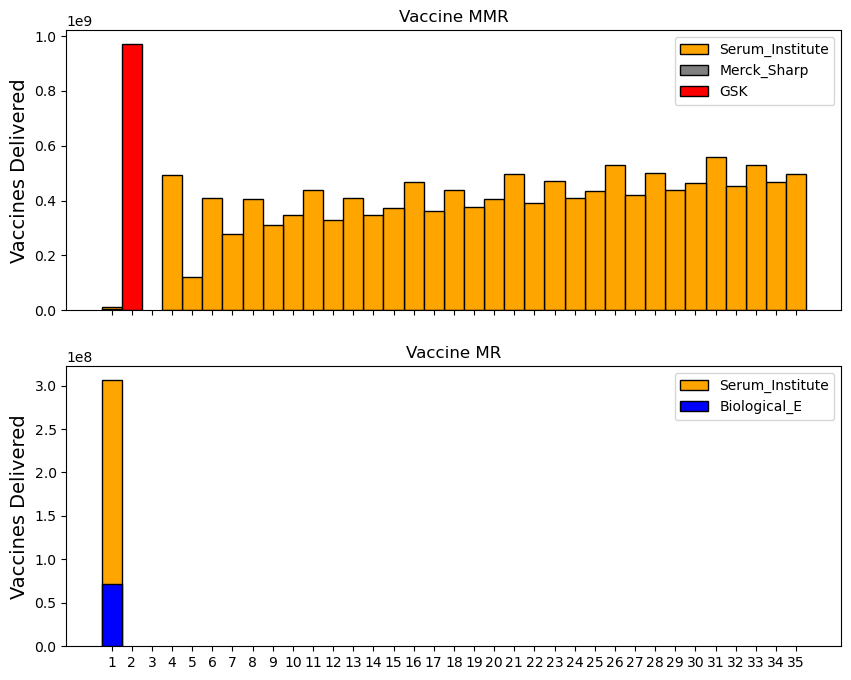

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Using DataFrame.insert() to add a column
F_values_df.insert(2, "Color", ['green', 'blue', 'orange', 'red', 'grey', 'purple','yellow','maroon'], True)

# Create subplots for each vaccine
fig, axs = plt.subplots(nrows=len(X_data['Vaccine'].unique()), figsize=(10, 8), sharex=True)

# Define unique colors for each producer
producer_colors = {'Biological_E': 'blue', 'Serum_Institute': 'orange', 'PT_Bio': 'green', 'GSK': 'red', 'Merck_Sharp':'grey'}

# Plot stacked bars for each vaccine
for i, (vaccine, group) in enumerate(X_data.groupby('Vaccine')):
    producers = group['Producer'].unique()
    
    for producer in producers:
        producer_data = group[group['Producer'] == producer]
        axs[i].bar(producer_data['Start'], producer_data['Value'], label=producer, bottom=np.zeros(len(producer_data)), width=1.0, edgecolor='black', linewidth=1, color=producer_colors.get(producer, 'gray'))

    axs[i].set_title(f'Vaccine {vaccine}')
    axs[i].set_ylabel('Vaccines Delivered', fontsize=14)
    axs[i].legend()
    

# Set x-axis ticks for each year
for ax in axs.flat:
    ax.set_xticks(np.arange(min(X_data['Start']), max(X_data['End']) + 1, 1))
    # ax.set_xlabel('Time (Start)')


# plt.suptitle('Measles vaccination by Vaccine/Producer')
# plt.savefig('vax_as_antigens_35_MCV.png', bbox_inches='tight', pad_inches=0.1)
plt.show()


In [20]:
#CHECK I levels
with open('MMR_Penta_S2_D2_overlap_cap.json') as json_file:
    F_results = json.load(json_file)

    

# List of keywords to search for
keywords_to_search = ["I["]

# Initialize a dictionary to store grouped results
grouped_results = {keyword: [] for keyword in keywords_to_search}

# Search for keywords in the JSON keys and group the results
for key, value in F_results.items():
    for keyword in keywords_to_search:
        if keyword in key:
            grouped_results[keyword].append({key: value})


In [21]:
# Extract the 'M' group
m_group = grouped_results.get('I[', [])

# Filter dictionaries starting with 'X' or 'F' and exclude those with 'X_tilde'
filtered_dicts = [
    entry for entry in m_group
    if ('MMR' in key for key in entry)
]

# filtered_dicts

In [22]:
import pandas as pd

data = [
    {'I[DTwP-Hib,7]': 0.0},
    {'I[Penta,0]': 12542.0},
    {'I[DTwP-Hib,6]': 0.0},
    {'I[HepB,29]': 0.0},
    {'I[DTwP,18]': 53097868.398522735},
]

# Extracting data and creating a DataFrame
df_data = []
for item in filtered_dicts:
    key, value = item.popitem()
    vaccine_start = key.find('I[') + 2
    vaccine_end = key.find(',', vaccine_start)
    year_start = vaccine_end + 1
    year_end = key.find(']', year_start)
    
    vaccine = key[vaccine_start:vaccine_end]
    year = key[year_start:year_end]
    
    df_data.append({'Vaccine': vaccine, 'Year': year, 'Value': value})

df = pd.DataFrame(df_data)

# Display the DataFrame
df


,Vaccine,Year,Value
0,DTwP,9,0.000000e+00
1,DTwP-Hib,31,0.000000e+00
2,Penta,6,0.000000e+00
3,Hexa,8,0.000000e+00
4,Hexa,26,0.000000e+00
...,...,...,...
607,PCV,24,0.000000e+00
608,Td,29,2.826266e+06
609,IPV,35,0.000000e+00
610,HPV,33,1.438569e+08


In [23]:
df[(df.Vaccine == "MMR") & (df.Value != 0)].sort_values(by='Year')

,Vaccine,Year,Value
516,MMR,2,322200000.0
293,MMR,4,193151695.0
